In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn tensorflow imbalanced-learn shap

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("/content/ai4i2020.csv")

In [ ]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M,Reconstruction_Error,Anomaly
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True,0.024385,False
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False,0.005162,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False,0.037164,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False,0.029826,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False,0.046321,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
df["Machine failure"].value_counts()

,count
Machine failure,
0,9661
1,339


In [ ]:
df = df.drop(["UDI", "Product ID"], axis=1)

In [ ]:
df = pd.get_dummies(df, columns=["Type"], drop_first=True)

In [ ]:
X = df.drop("Machine failure", axis=1)

y = df["Machine failure"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.51753137533963), 1: np.float64(14.760147601476016)}


In [ ]:
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9539 - loss: 0.6139 - val_accuracy: 0.9944 - val_loss: 0.2054
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.1467 - val_accuracy: 1.0000 - val_loss: 0.0657
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0793 - val_accuracy: 1.0000 - val_loss: 0.0407
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0672 - val_accuracy: 1.0000 - val_loss: 0.0306
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0633 - val_accuracy: 1.0000 - val_loss: 0.0316
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0608 - val_accuracy: 1.0000 - val_loss: 0.0309
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9989 - loss: 0.0579 - val_accuracy: 1.0000 - val_loss: 0.0265
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9989 - loss: 0.0569 - val_accuracy: 1.

In [ ]:
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



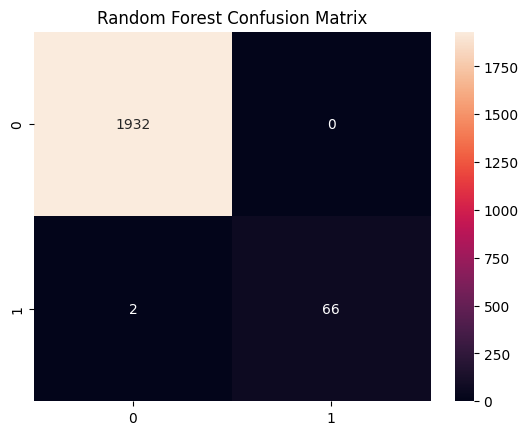

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
X_noisy = X.copy()

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

noise = np.random.normal(0, 0.1, X_noisy[numerical_cols].shape)

X_noisy[numerical_cols] = X_noisy[numerical_cols] + noise

In [ ]:
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_n = scaler.fit_transform(X_train_n)

X_test_n = scaler.transform(X_test_n)

In [ ]:
rf.fit(X_train_n, y_train_n)

y_pred_rf_n = rf.predict(X_test_n)

print(classification_report(y_test_n, y_pred_rf_n))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from sklearn.linear_model import LogisticRegression

lr_noisy = LogisticRegression(max_iter=1000)

lr_noisy.fit(X_train_n, y_train_n)

y_pred_lr_n = lr_noisy.predict(X_test_n)

print(classification_report(y_test_n, y_pred_lr_n))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
model.fit(
    X_train_n,
    y_train_n,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0499 - val_accuracy: 0.9969 - val_loss: 0.0216
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9955 - loss: 0.0233 - val_accuracy: 0.9975 - val_loss: 0.0121
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9973 - loss: 0.0169 - val_accuracy: 0.9994 - val_loss: 0.0080
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9983 - loss: 0.0135 - val_accuracy: 0.9994 - val_loss: 0.0057
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9983 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0099 - val_accuracy: 0.9994 - val_loss: 0.0037
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9987 - loss: 0.0091 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0085 - val_accuracy: 1.

In [ ]:
y_pred_nn_n = (model.predict(X_test_n) > 0.5).astype(int)

print(classification_report(y_test_n, y_pred_nn_n))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
sm = SMOTE(random_state=42)

X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [ ]:
print(y_resampled.value_counts())

Machine failure
0    7729
1    7729
Name: count, dtype: int64


In [ ]:
lr.fit(X_resampled, y_resampled)

y_pred_lr_sm = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr_sm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
rf.fit(X_resampled, y_resampled)

y_pred_rf_sm = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf_sm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_resampled_scaled = scaler.fit_transform(X_resampled)

X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_sm = Sequential()

model_sm.add(Dense(32, activation='relu', input_shape=(X_resampled_scaled.shape[1],)))

model_sm.add(Dense(16, activation='relu'))

model_sm.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_sm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_sm = model_sm.fit(
    X_resampled_scaled,
    y_resampled,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9584 - loss: 0.1706 - val_accuracy: 0.9738 - val_loss: 0.1006
Epoch 2/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9905 - loss: 0.0437 - val_accuracy: 0.9738 - val_loss: 0.0967
Epoch 3/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9905 - loss: 0.0399 - val_accuracy: 0.9738 - val_loss: 0.0844
Epoch 4/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0371 - val_accuracy: 0.9738 - val_loss: 0.0796
Epoch 5/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0339 - val_accuracy: 0.9738 - val_loss: 0.0701
Epoch 6/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0315 - val_accuracy: 0.9738 - val_loss: 0.0682
Epoch 7/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0284 - val_accuracy: 0.9745 - val_loss: 0.0531
Epoch 8/20
387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0256 - val_accuracy: 0.

In [ ]:
y_pred_nn_sm = (model_sm.predict(X_test_scaled) > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nn_sm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       0.96      0.96      0.96        68

    accuracy                           1.00      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
!pip install shap

In [ ]:
import shap
import pandas as pd

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

In [ ]:
explainer = shap.TreeExplainer(rf)

In [ ]:
shap_values = explainer.shap_values(X_test_df)

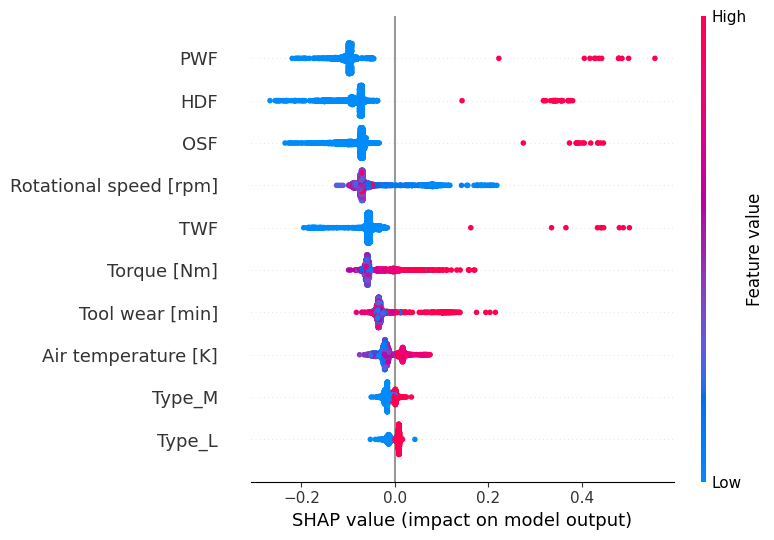

In [ ]:
shap.summary_plot(
    shap_values[:,:,1],
    X_test_df,
    max_display=10
)

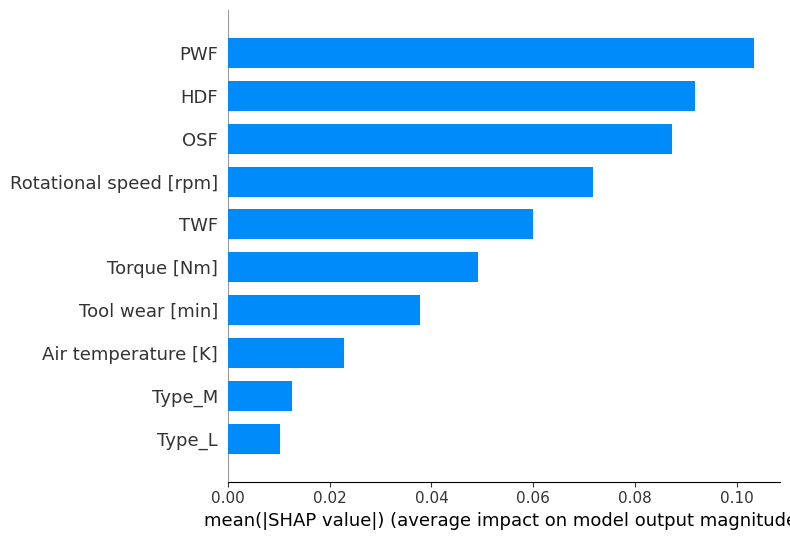

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import shap

plt.figure(figsize=(12,6))

shap.summary_plot(
    shap_values[:,:,1],
    X_test_df,
    plot_type="bar",
    max_display=10,

)

plt.tight_layout()
plt.show()

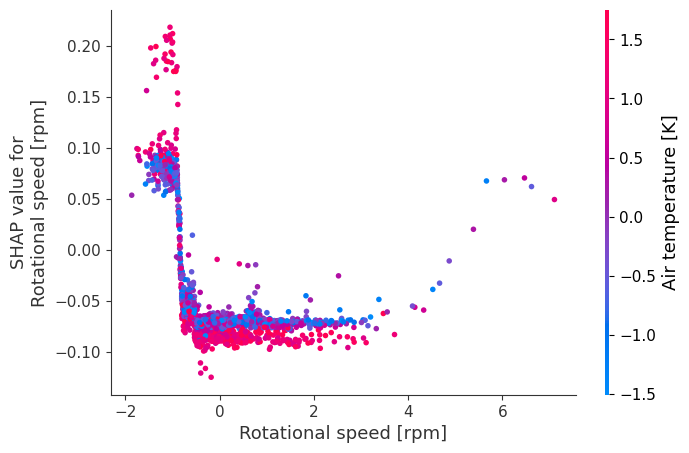

In [ ]:
shap.dependence_plot(
    "Rotational speed [rpm]",
    shap_values[:,:,1],
    X_test_df
)

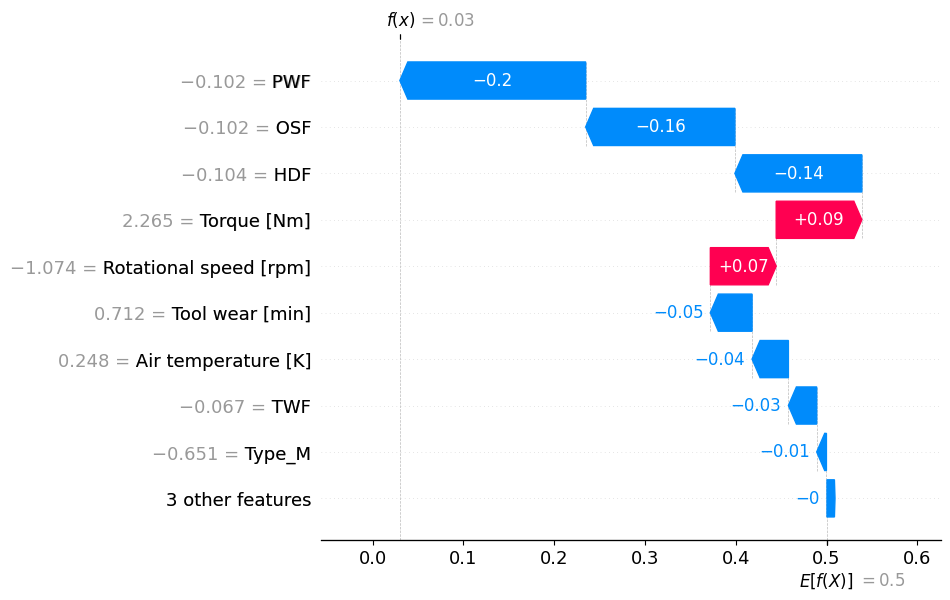

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0,:,1],
        base_values=explainer.expected_value[1],
        data=X_test_df.iloc[0],
        feature_names=X_test_df.columns
    )
)

In [ ]:
!pip install lime

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

In [ ]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['No Failure', 'Failure'],
    mode='classification'
)

In [ ]:
X_test_df = pd.DataFrame(
    X_test,
    columns=X.columns
)

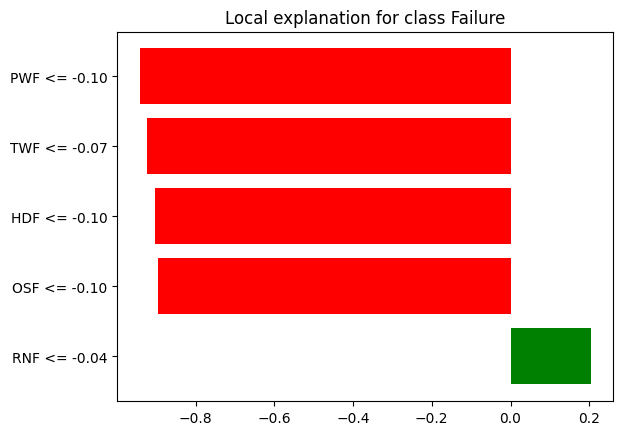

In [ ]:
def predict_keras_proba(x):
    preds = model.predict(x, verbose=0).flatten()
    return np.column_stack([1 - preds, preds])

exp = explainer.explain_instance(
    X_test[0],
    predict_keras_proba,
    num_features=5
)

fig = exp.as_pyplot_figure()

In [ ]:
models = ['Logistic Regression', 'Random Forest', 'Neural Network']

normal_f1 = [0.99, 1.00, 0.99]

noisy_f1 = [0.97, 0.99, 0.96]

smote_f1 = [0.98, 0.99, 0.97]

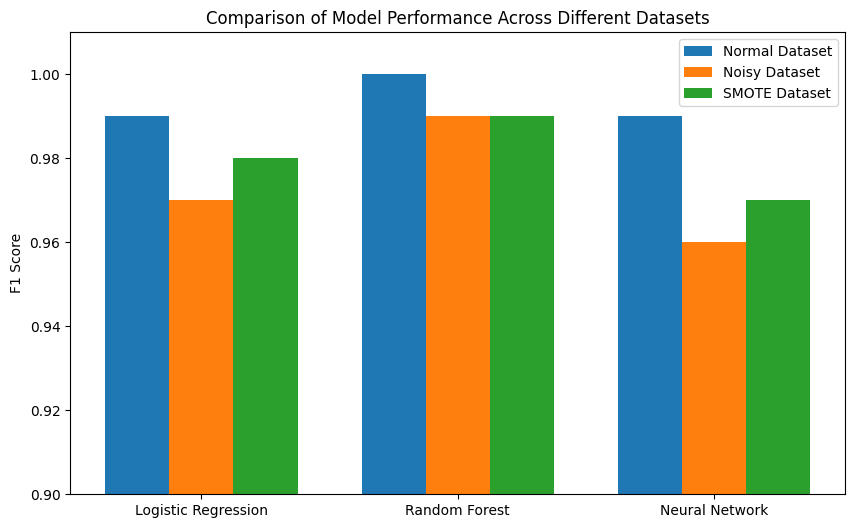

In [ ]:
x = np.arange(len(models))

width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, normal_f1, width, label='Normal Dataset')

plt.bar(x, noisy_f1, width, label='Noisy Dataset')

plt.bar(x + width, smote_f1, width, label='SMOTE Dataset')

plt.xticks(x, models)

plt.ylabel('F1 Score')

plt.title('Comparison of Model Performance Across Different Datasets')

plt.ylim(0.9, 1.01)

plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [ ]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df[features]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
input_dim = X_scaled.shape[1]

input_layer = Input(shape=(input_dim,))

encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(4, activation='relu')(encoded)

decoded = Dense(8, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.8511 - val_loss: 0.4780
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2906 - val_loss: 0.1750
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1047 - val_loss: 0.0855
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0638 - val_loss: 0.0651
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0521 - val_loss: 0.0579
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0463 - val_loss: 0.0544
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0426 - val_loss: 0.0535
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0402 - val_loss: 0.0487
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0380 - val_loss: 0.0491
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0358 - val_loss: 0.0432
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0332 - val_loss: 0.0386
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/st

In [ ]:
reconstructions = autoencoder.predict(X_scaled)

mse = np.mean(np.square(X_scaled - reconstructions), axis=1)

df['Reconstruction_Error'] = mse

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
threshold = np.percentile(mse, 95)

df['Anomaly'] = df['Reconstruction_Error'] > threshold

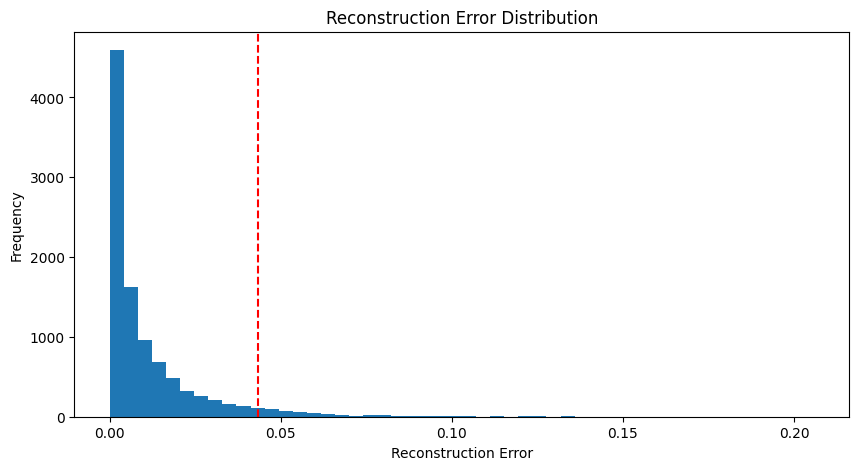

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(mse, bins=50)

plt.axvline(threshold, color='red', linestyle='--')

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")

plt.show()